In [1]:
import pandas as pd
import numpy as np

from analyze_src.basic_data_inspection import DataInspector, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy
from analyze_src.missing_values_analysis import SimpleMissingValuesAnalysis
from src.feature_engineering import FeatureEngineerHandler, DateTimeFeatureStrategy, MonsoonSeasonFeatureStrategy
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis
from analyze_src.bivariate_analysis import BivariateAnalysisContext, NumericalNumericalAnalysis, CategoricalNumericalAnalysis, CategoricalCategoricalAnalysis
from analyze_src.multivariate_analysis import multivariate_analysis

ModuleNotFoundError: No module named 'pandas'

In [2]:
# Set display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [3]:
# Load the data
data_path = "../extracted_data/daily-rainfall-at-state-level.csv"
df = pd.read_csv(data_path)

In [4]:
# Inspect the data
data_inspector = DataInspector(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df)


Data Type and Non-null Count
<class 'pandas.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  str    
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  str    
 4   actual      187714 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 16.5 MB


In [5]:
 # Change the Inspection Strategy
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df)


Summary Statistics (Numerical Features)
                  id     state_code         actual            rfs  \
count  204876.000000  204876.000000  187714.000000  199011.000000   
mean   102437.500000      19.166667       3.990693       9.643683   
std     59142.751213      11.171668       9.512507      27.504865   
min         0.000000       1.000000       0.000000       0.000000   
25%     51218.750000       9.750000       0.000000       0.000000   
50%    102437.500000      18.500000       0.150000       0.063856   
75%    153656.250000      29.250000       3.890000       5.685068   
max    204875.000000      38.000000     283.000000     658.765073   

              normal      deviation  
count  193358.000000  173855.000000  
mean        4.654058      38.516222  
std         7.369770    1367.744520  
min         0.000000    -100.000000  
25%         0.420000    -100.000000  
50%         1.870000     -89.060000  
75%         6.760000      -9.045000  
max        97.680000  362300.0000

### 1. Data Types Overview

- The dataset contains **204,876 entries** and **8 columns**.
- 6 columns are numerical and 2 are categorical.
- Some numerical features (`state_code, id`) represent categorical or identifier information and should not be treated as continuous variable.
- Categorical features such as `state_name` will require encoding before model training.
- Several rainfall features contain missing values, which must be addressed during preprocessing.

### 2. Summary Statistics

- The rainfall-related variables (`actual, rfs, normal`) show strong right skewness, with median significantly lower than means and extreme maximum values (e.g., `actual`: median = 0.15, mean = 3.99, max = 283).
- This indicates that the data is not normally distributed and may require transformation before model training.
- The `Deviation` column contains extreme outliers that require further investigation
- Dataset appears to be structured as a panel dataset across 36 states over multiple dates

## FeatureEngineering

In [6]:
FeatureEngineer = FeatureEngineerHandler(DateTimeFeatureStrategy("date"))
FeatureEngineer.apply_feature_engineering(df)

,id,date,state_code,state_name,actual,rfs,normal,deviation,year,month,day
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0,2009,1,1
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0,2009,1,1
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0,2009,1,1
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0,2009,1,1
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0,2009,1,1
...,...,...,...,...,...,...,...,...,...,...,...
204871,204871,2024-07-27,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.40,NaN,2024,7,27
204872,204872,2024-07-28,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,8.30,NaN,2024,7,28
204873,204873,2024-07-29,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,5.40,NaN,2024,7,29
204874,204874,2024-07-30,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.30,NaN,2024,7,30


In [7]:
FeatureEngineer.set_strategy(MonsoonSeasonFeatureStrategy("month"))
FeatureEngineer.apply_feature_engineering(df)

,id,date,state_code,state_name,actual,rfs,normal,deviation,year,month,day,monsoon_season
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0,2009,1,1,0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0,2009,1,1,0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0,2009,1,1,0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0,2009,1,1,0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0,2009,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
204871,204871,2024-07-27,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.40,NaN,2024,7,27,1
204872,204872,2024-07-28,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,8.30,NaN,2024,7,28,1
204873,204873,2024-07-29,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,5.40,NaN,2024,7,29,1
204874,204874,2024-07-30,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.30,NaN,2024,7,30,1


## Missing Values


 Values Count by Column:
actual       17162
rfs           5865
normal       11518
deviation    31021
dtype: int64

 Visualizing Missing Values:


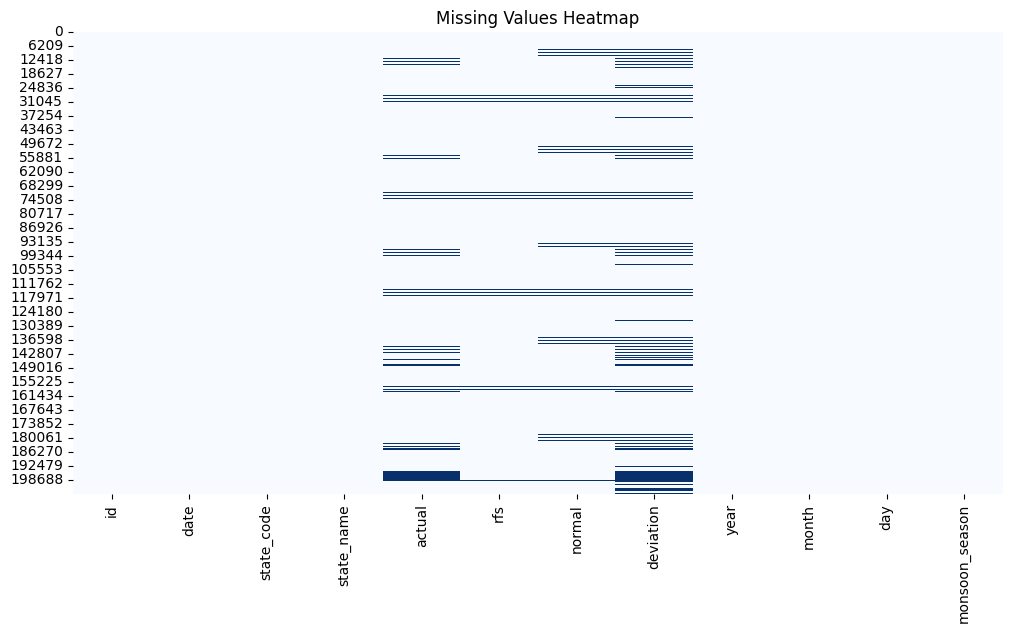

In [8]:
# Missing Values Analysis
missing_values_analyzer = SimpleMissingValuesAnalysis()
missing_values_analyzer.analyze(df)

# Missing Values Heatmap Insights

### 1. Color Representation Missingness.

- The heatmap uses a color gradient to represent the presence (`dark blue`) and absence (`light blue`) of missing values in the dataset.

### 2. Identifying Missing Values.

- Look for columns with significant amount of `light blue`. There columns have higher proportion of missing values.
    - For instance, in your heatmap, columns like `actual`, `normal`, and `deviation` have substantial `light blue`, indicating that these feature have missing values.

# Univariate Analysis

In [9]:
# filters for numerical features
univariate_filters_rainy = {
    "actual": lambda x: x > 0,
    "rfs": lambda x: x > 0,
    "deviation": lambda x: x != -100
}

In [10]:
# Analysis split into two views — all days and rainy days only (actual > 0) to handle zero-inflated nature of rainfall data.

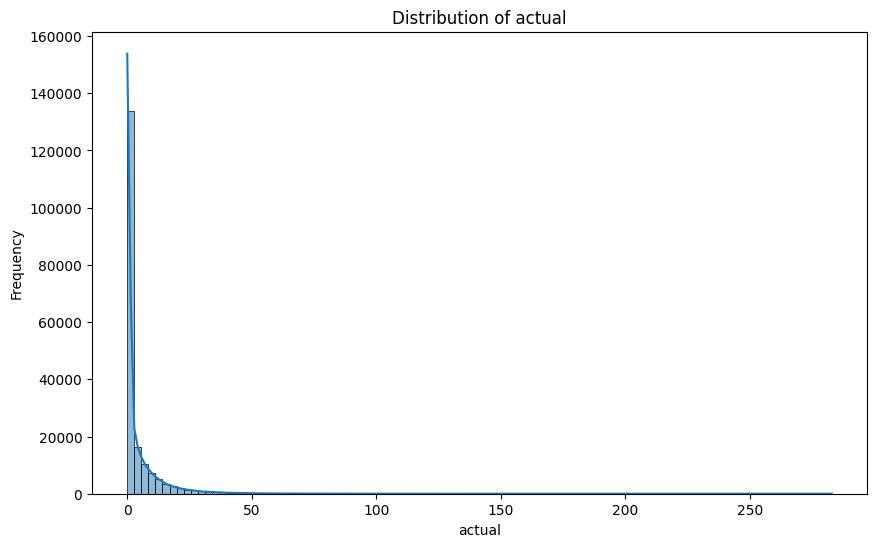

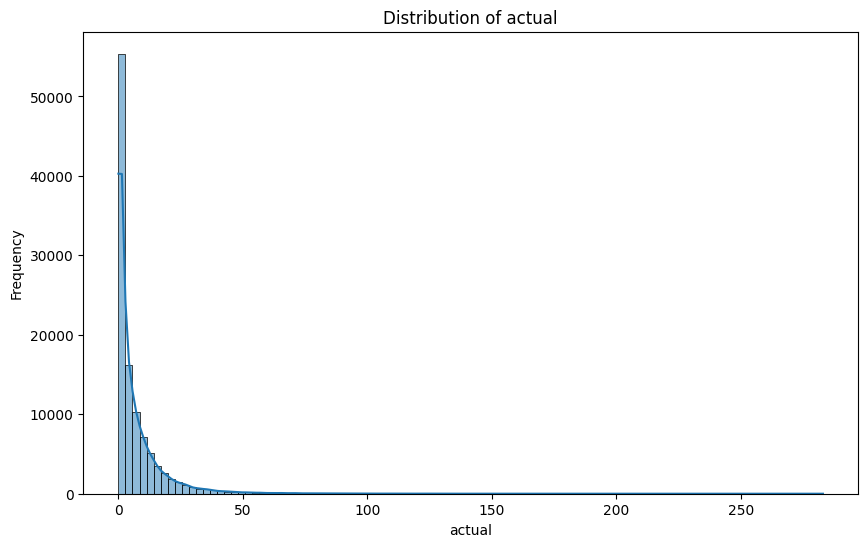

In [11]:
univariate_analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, "actual")
univariate_analyzer.execute_analysis(df, "actual", univariate_filters_rainy)

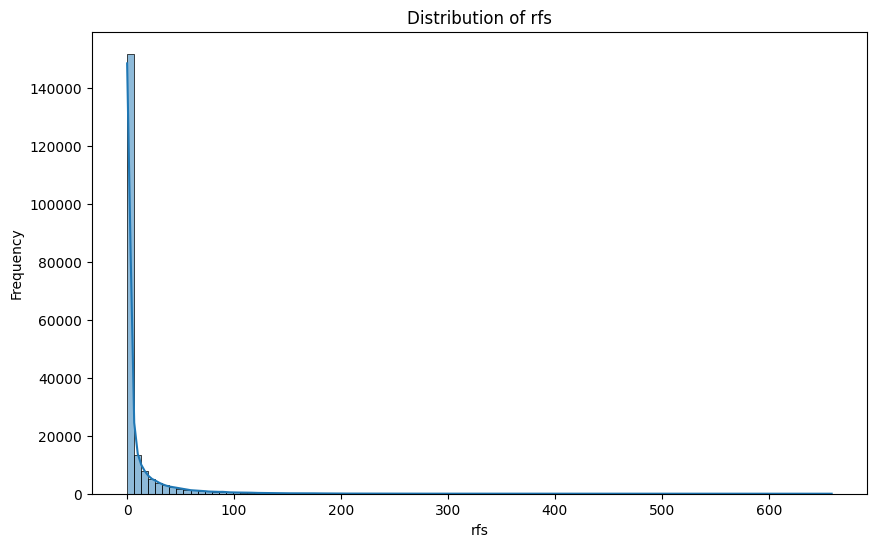

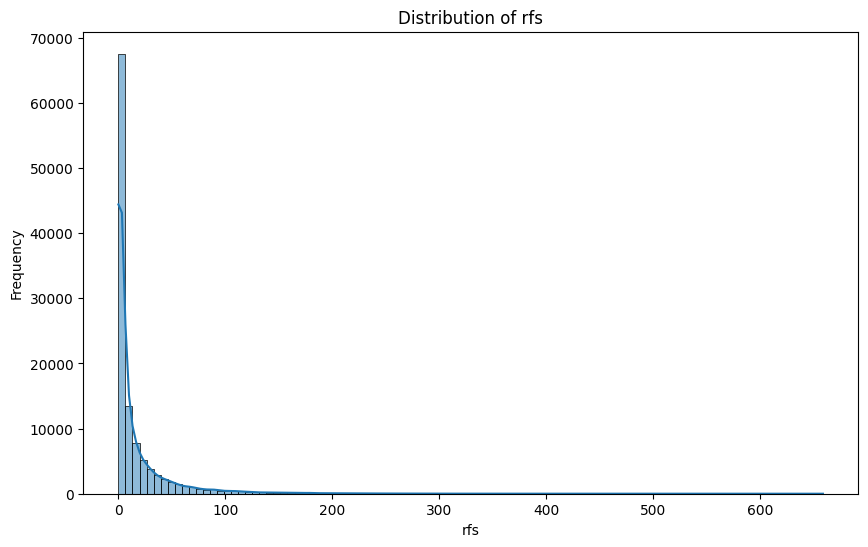

In [12]:
univariate_analyzer.execute_analysis(df, "rfs")
univariate_analyzer.execute_analysis(df, "rfs", univariate_filters_rainy)

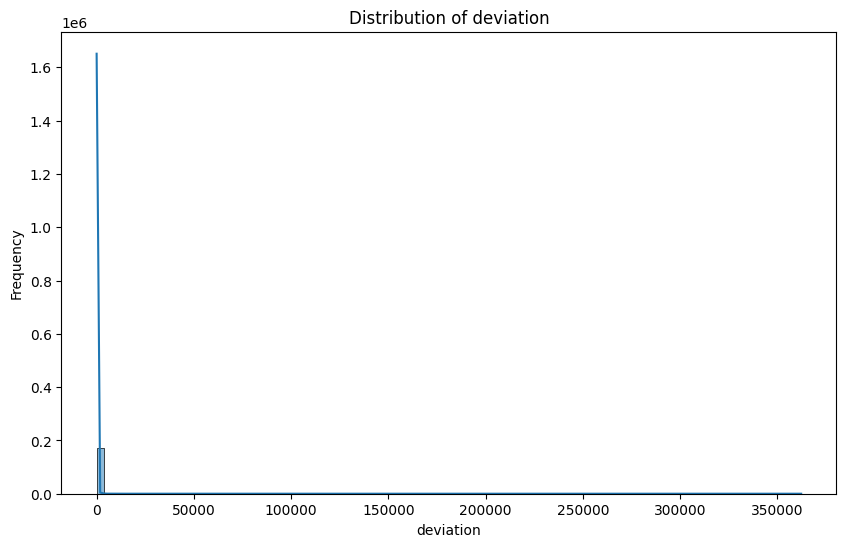

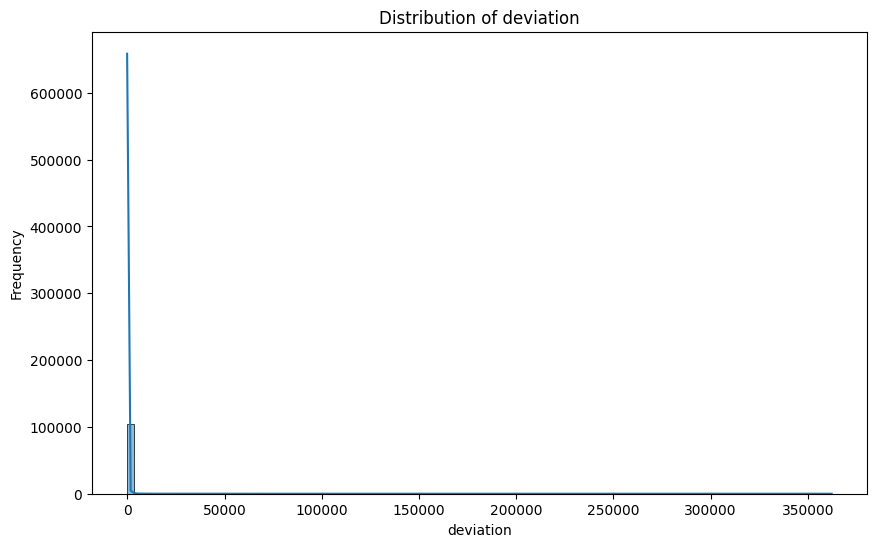

In [13]:
univariate_analyzer.execute_analysis(df, "deviation")
univariate_analyzer.execute_analysis(df, "deviation", univariate_filters_rainy)

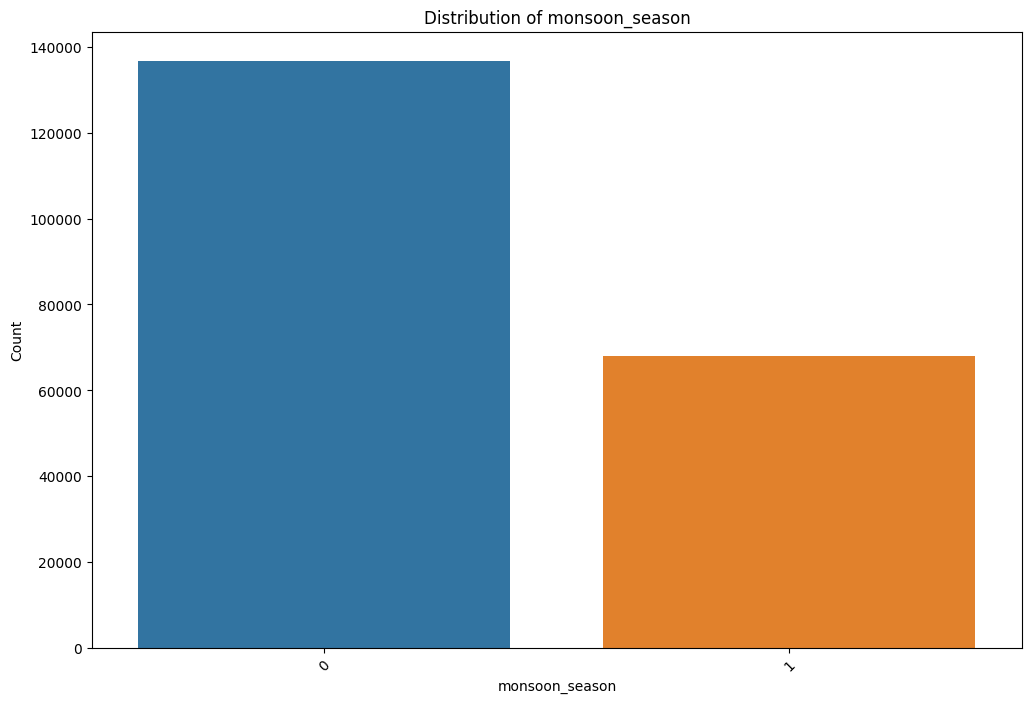

In [14]:
univariate_analyzer.set_strategy(CategoricalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, "monsoon_season")

# Bivariate Analysis

In [15]:
bivariate_filters_rainy = {
    "actual": lambda x: x > 0,
    "normal": lambda x: x > 0,
    "rfs": lambda x: x > 0,
    "deviation": lambda x: x != -100
}

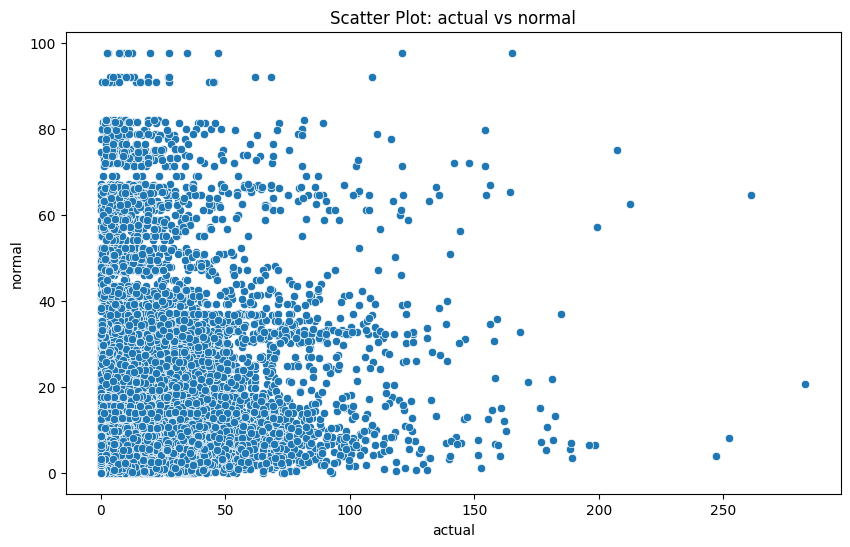

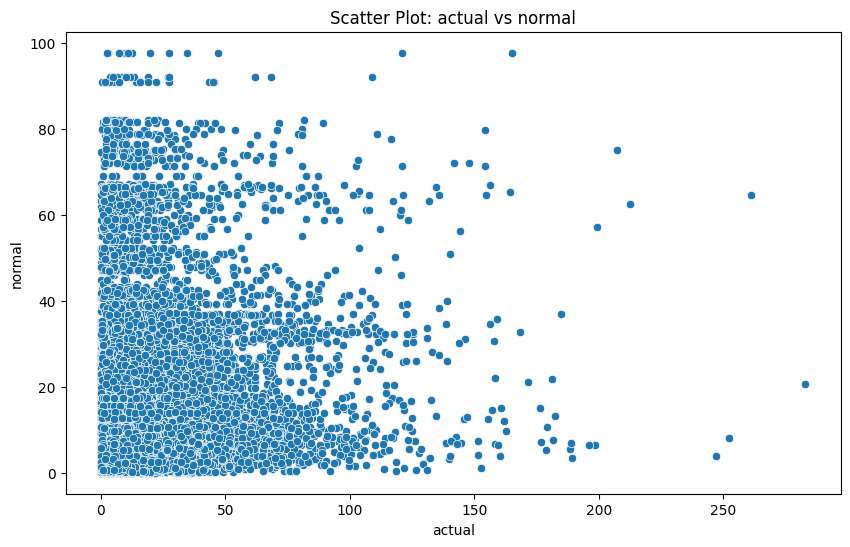

In [16]:
bivariate_context = BivariateAnalysisContext(NumericalNumericalAnalysis())
bivariate_context.analyze(df, "actual", "normal")
bivariate_context.analyze(df, "actual", "normal", bivariate_filters_rainy)

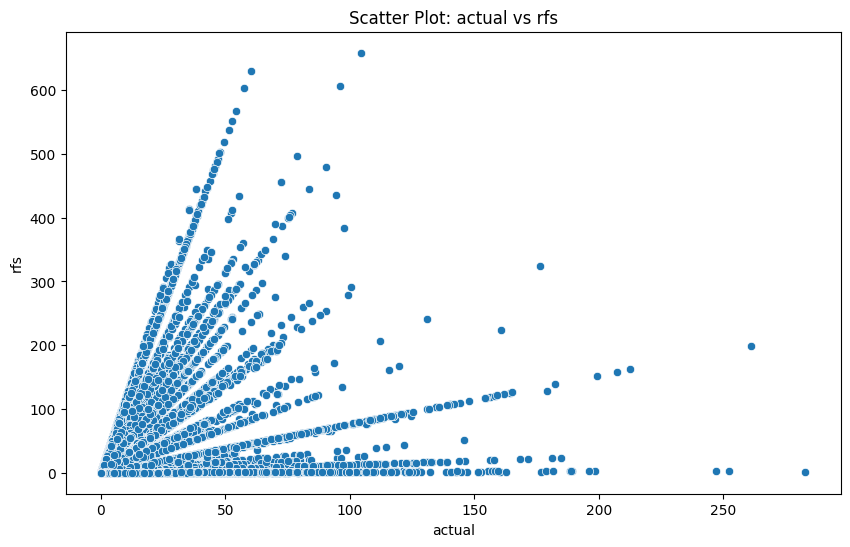

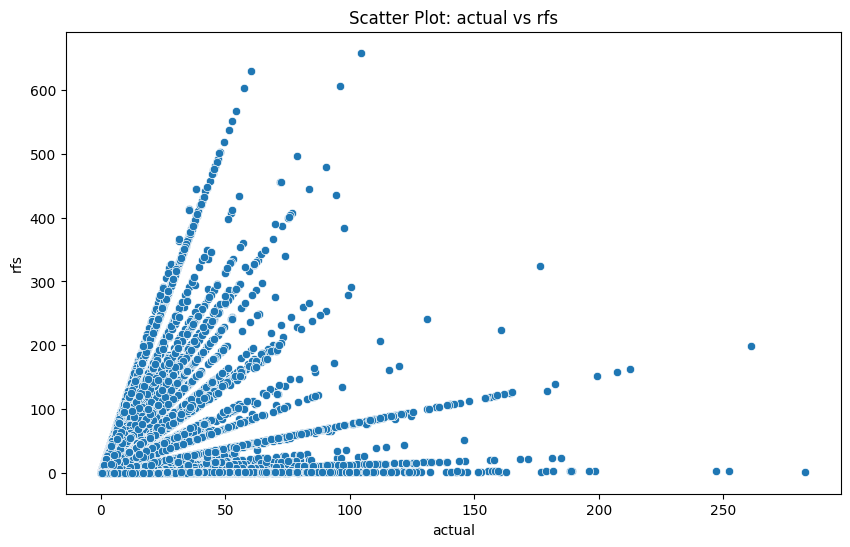

In [17]:
bivariate_context.analyze(df, "actual", "rfs")
bivariate_context.analyze(df, "actual", "rfs", bivariate_filters_rainy)

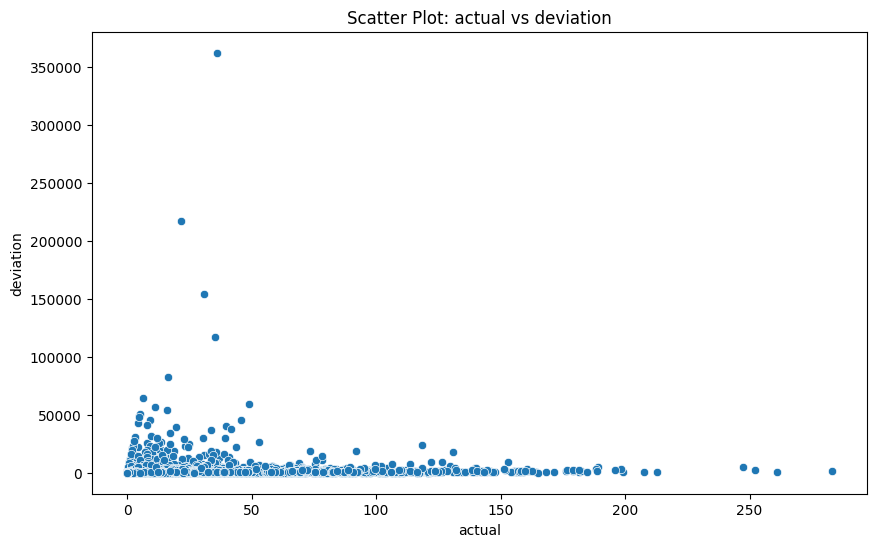

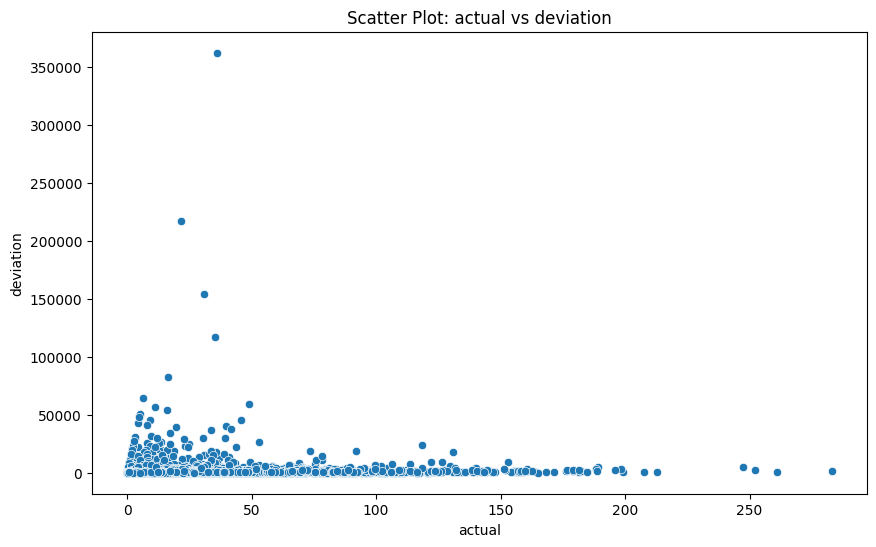

In [18]:
bivariate_context.analyze(df, "actual", "deviation")
bivariate_context.analyze(df, "actual", "deviation", bivariate_filters_rainy)

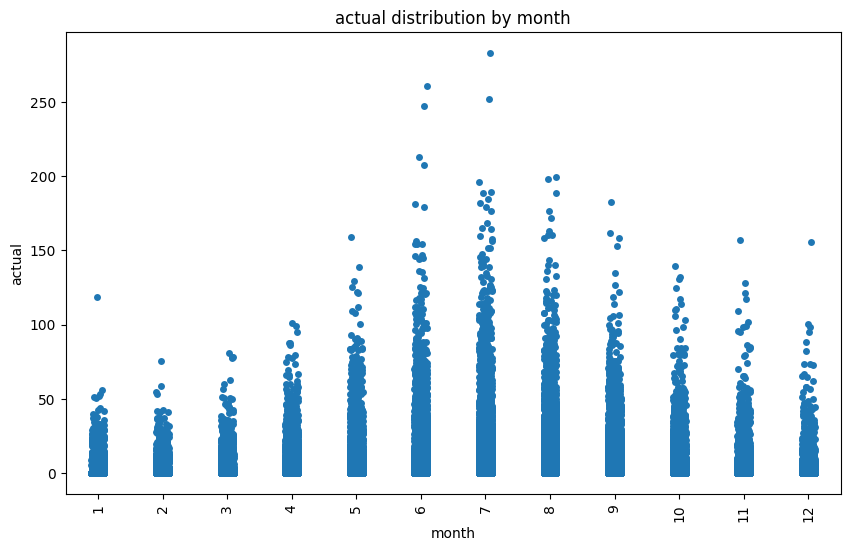

In [19]:
bivariate_context.set_strategy(CategoricalNumericalAnalysis(plot="strip"))
bivariate_context.analyze(df, "month", "actual")

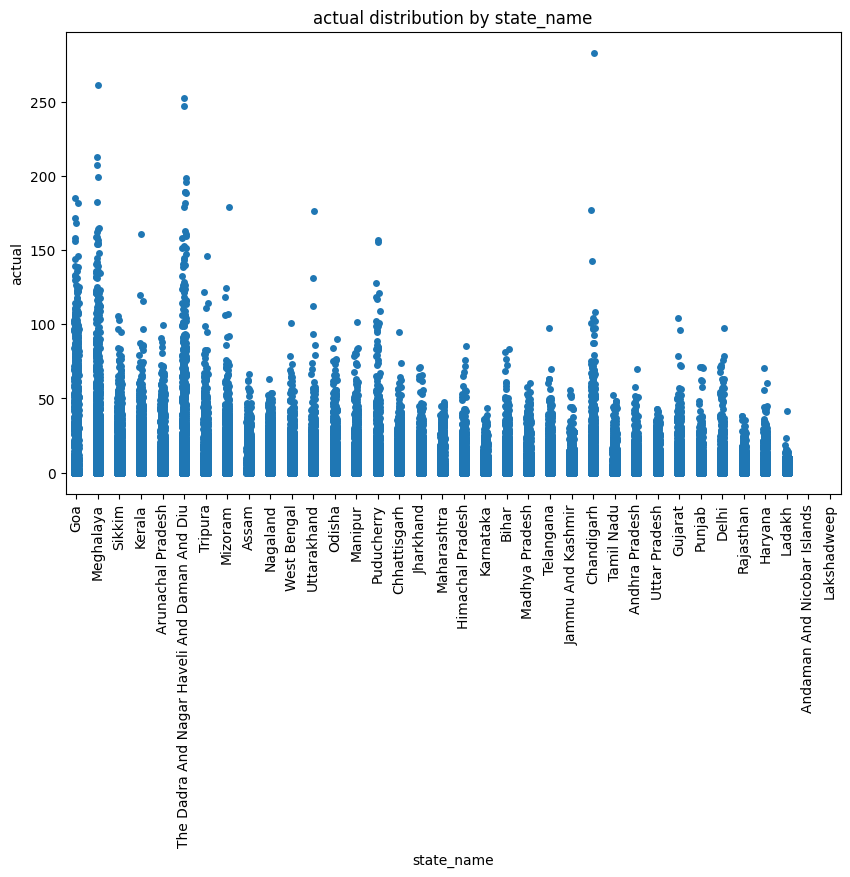

In [20]:
bivariate_context.analyze(df, "state_name", "actual", sort_order="descending")

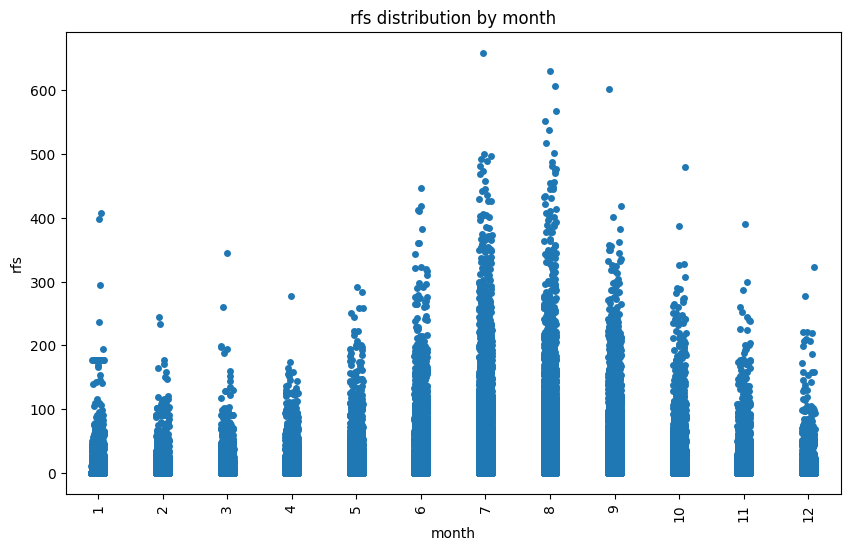

In [21]:
bivariate_context.analyze(df, "month", "rfs")

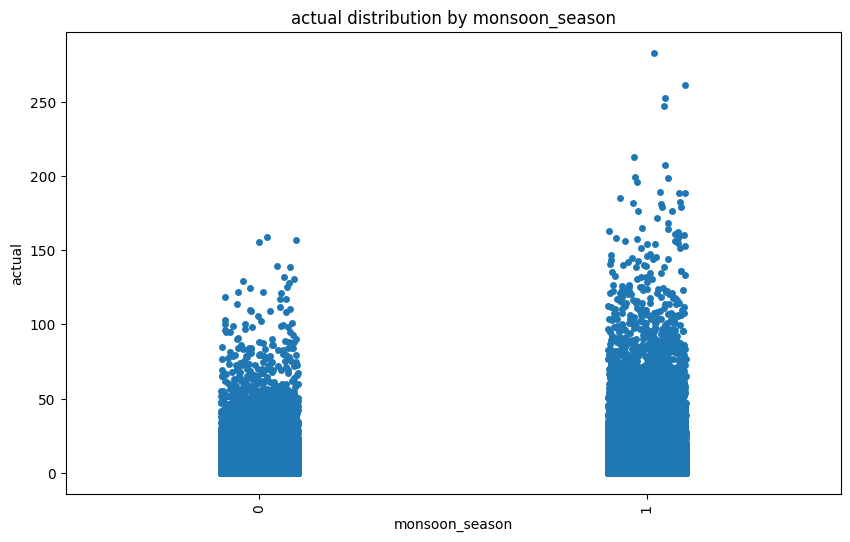

In [22]:
bivariate_context.analyze(df, "monsoon_season", "actual")

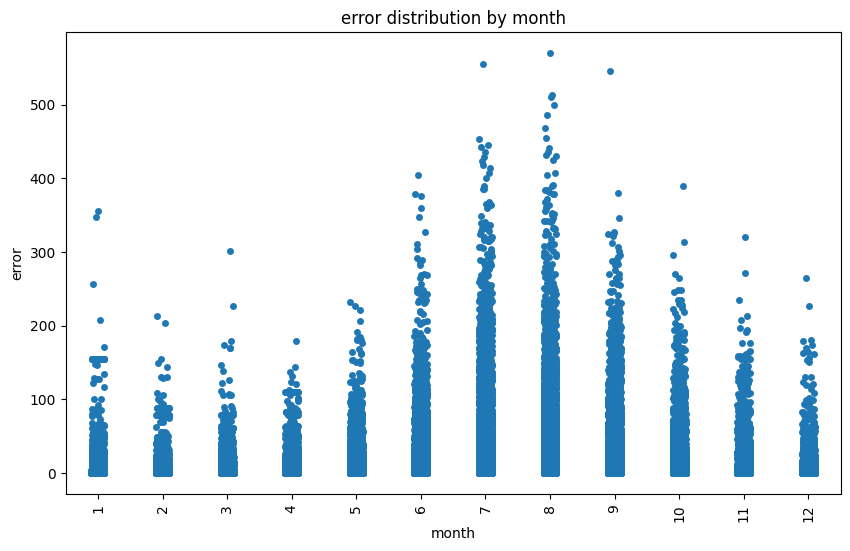

In [23]:
df['error'] = abs(df['actual'] - df['rfs'])
df.groupby('month')['error'].mean()
bivariate_context.analyze(df, "month", "error")

# Insights from Univariate and Bivariate Analysis

## Univariate Insights

- column like actual, rfs and deviation show high right skewness.

## Bivariate Insights

- Government model (rfs) dramatically overestimates rainfall during peak monsoon season
- Deviation column have corrupt extreme values
- State and month are two strong predictors of rainfall
- Government model error concentrates in monsoon months (June-Sept)

# Multivariate Analysis

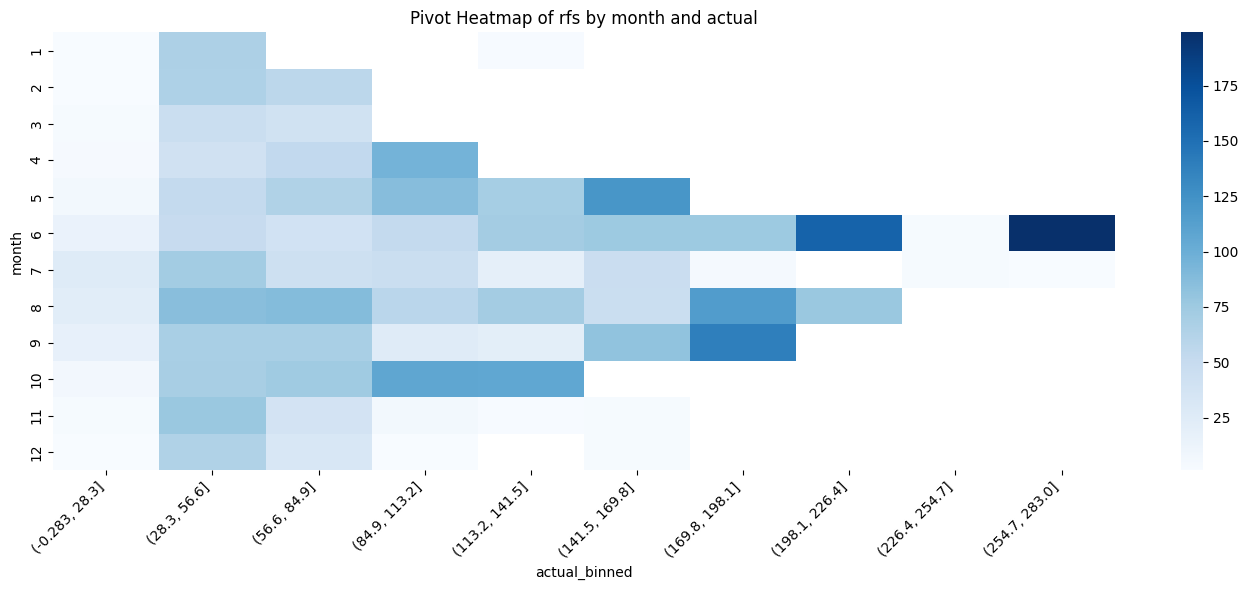

In [24]:
multivariate_analysis("pivot_heatmap", df=df, index="month", columns="actual", values="rfs")

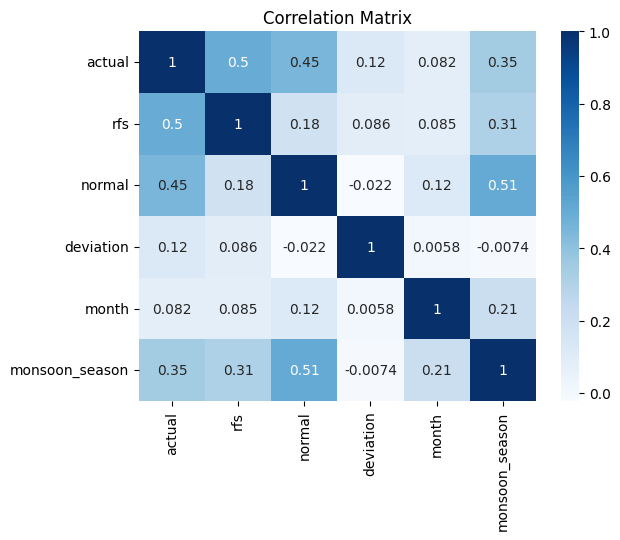

In [25]:
multivariate_analysis("correlation_matrix", df=df, features=["actual", "rfs", "normal", "deviation", "month", "monsoon_season"])

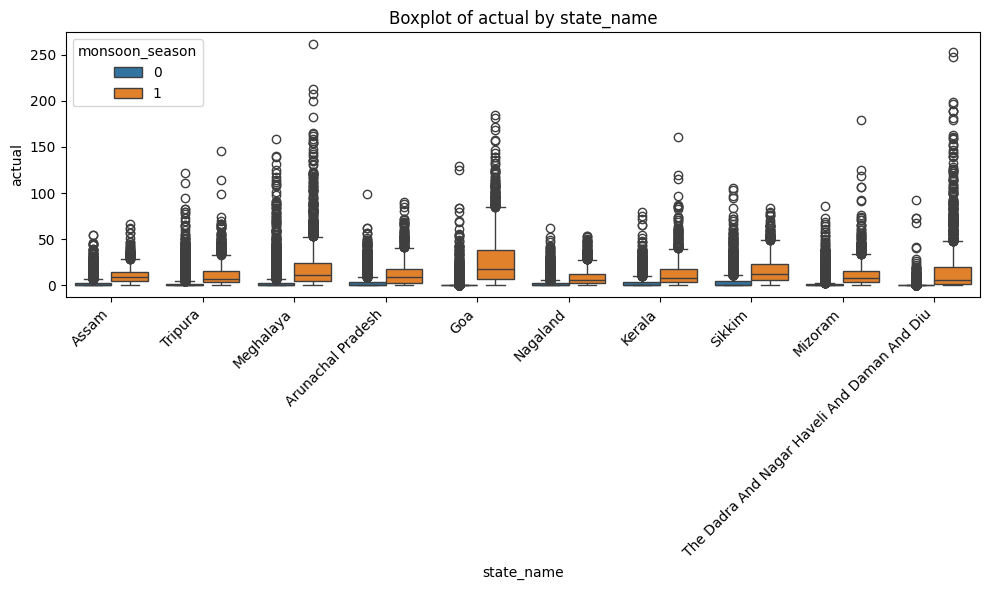

In [26]:
multivariate_analysis("boxplot", df=df, x="state_name", y="actual", hue="monsoon_season", top_n=10)

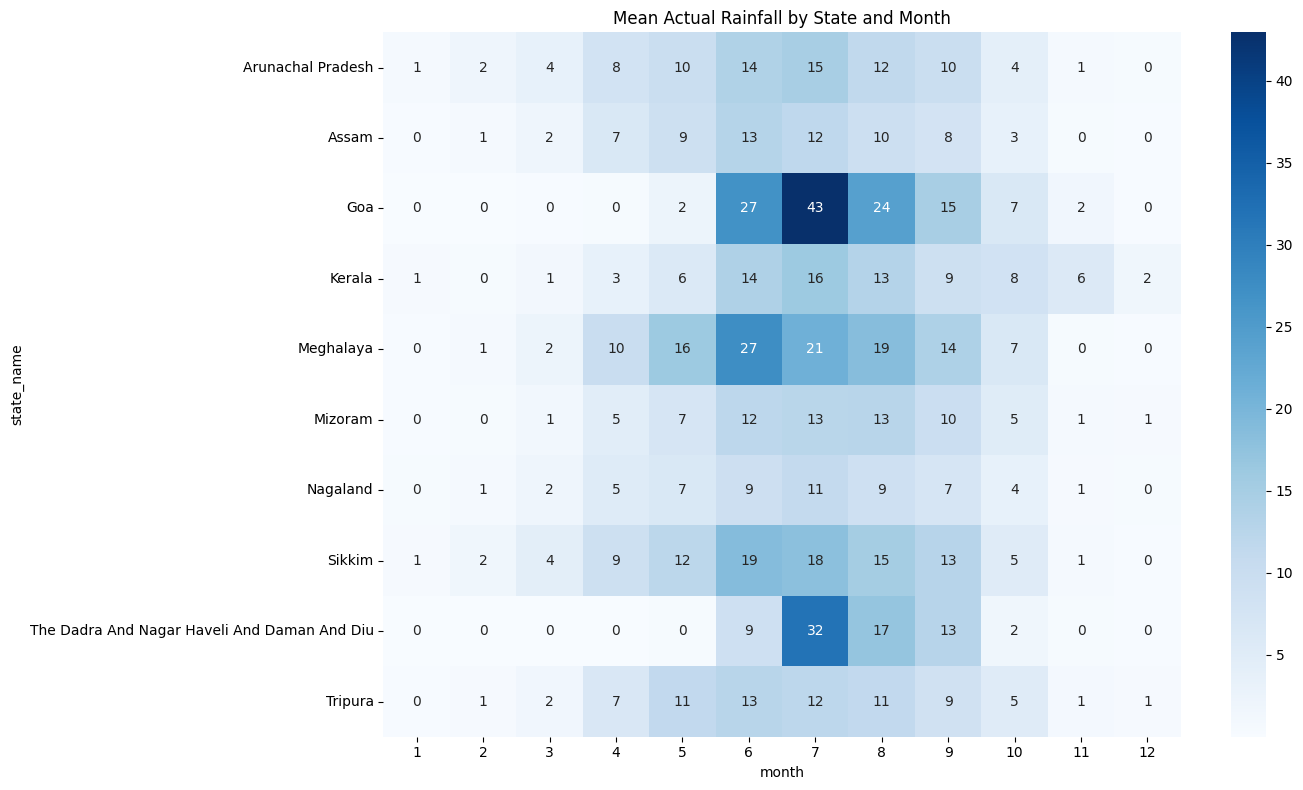

In [27]:
multivariate_analysis("state_month_heatmap", df=df, top_n=10)

## Multivariate Insights

- Government model overestimates most in june for high rainfall bins
- States + month interaction drives rainfall pattens
- Deviation column need fixing before model training

Text(0.5, 1.0, 'Log1p Transformed')

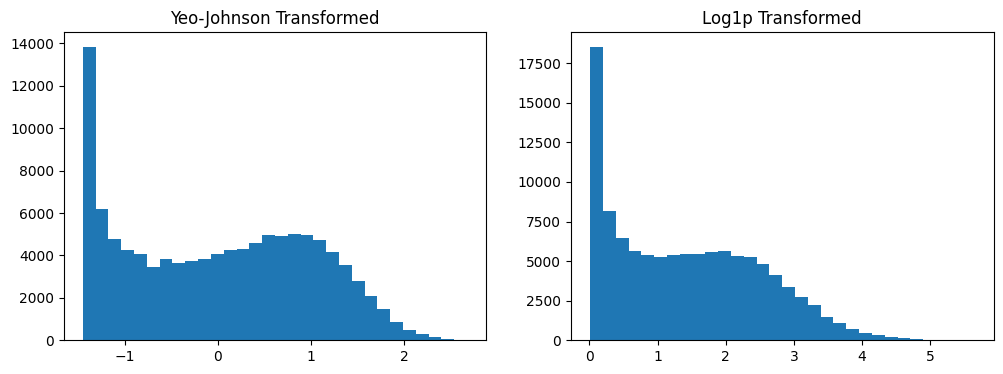

In [28]:
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed_data = pt.fit_transform(df[df['actual'] > 0]['actual'].values.reshape(-1, 1))
axes[0].hist(transformed_data, bins=30)
axes[0].set_title('Yeo-Johnson Transformed')

log_actual = np.log1p(df[df['actual'] > 0]['actual'])
axes[1].hist(log_actual, bins=30)
axes[1].set_title('Log1p Transformed')

(array([1.82977e+05, 3.74000e+03, 6.64000e+02, 2.01000e+02, 7.90000e+01,
        3.20000e+01, 1.30000e+01, 4.00000e+00, 2.00000e+00, 2.00000e+00]),
 array([-0.4195218 ,  2.55551687,  5.53055554,  8.50559421, 11.48063288,
        14.45567155, 17.43071021, 20.40574888, 23.38078755, 26.35582622,
        29.33086489]),
 <BarContainer object of 10 artists>)

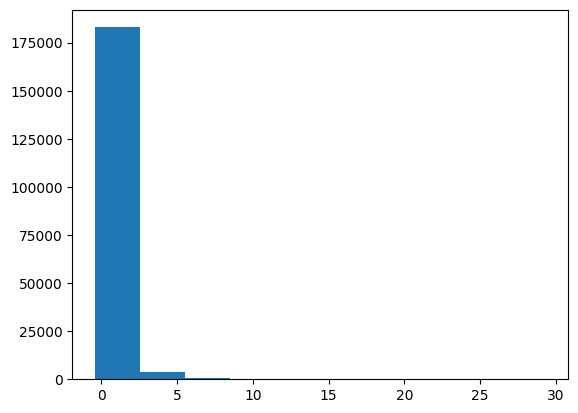

In [29]:
scaler = StandardScaler().fit_transform(df['actual'].values.reshape(-1, 1))
plt.hist(scaler)


In [30]:
df['actual'].describe()

count    187714.000000
mean          3.990693
std           9.512507
min           0.000000
25%           0.000000
50%           0.150000
75%           3.890000
max         283.000000
Name: actual, dtype: float64

<Axes: xlabel='rain_category'>

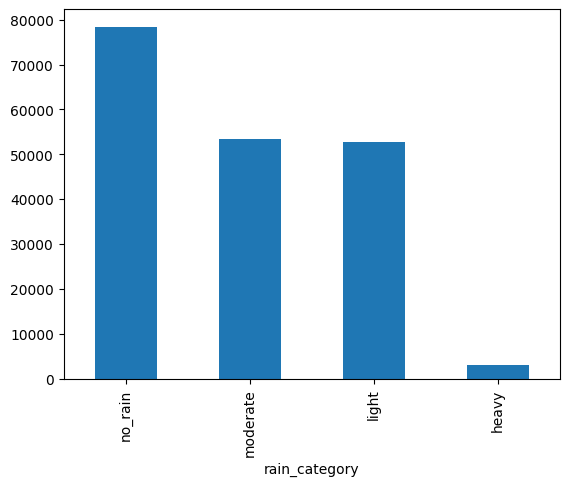

In [31]:
df['rain_category'] = pd.cut(df['actual'],
    bins=[-0.1, 0, 2.5, 35, 283],
    labels=['no_rain', 'light', 'moderate', 'heavy']
)
df['rain_category'].value_counts().plot(kind='bar')

<Axes: >

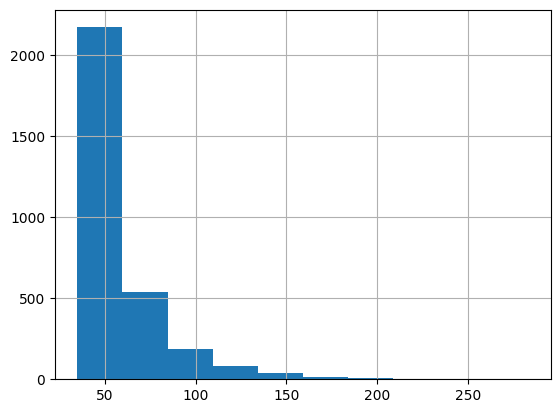

In [32]:
df[df['rain_category'] == "heavy"]["actual"].hist()

Text(0.5, 1.0, 'Log1p Transformed')

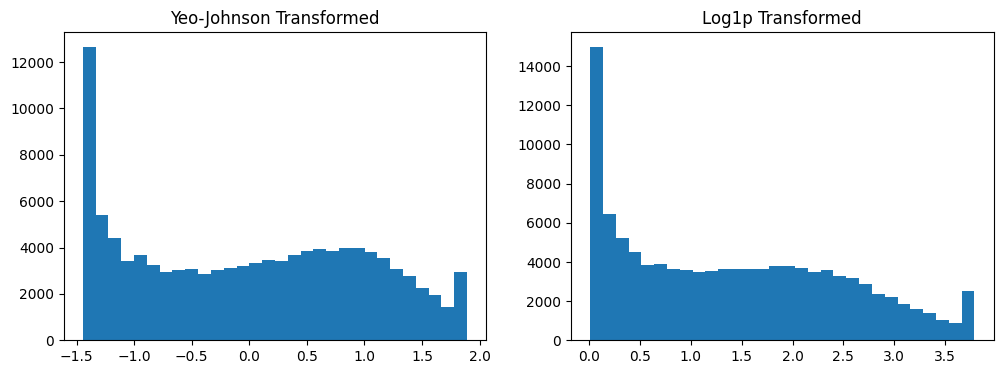

In [33]:
df['actual_capped'] = df['actual'].clip(upper=df['actual'].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed_data = pt.fit_transform(df[df['actual_capped'] > 0]['actual_capped'].values.reshape(-1, 1))
axes[0].hist(transformed_data, bins=30)
axes[0].set_title('Yeo-Johnson Transformed')

log_actual = np.log1p(df[df['actual_capped'] > 0]['actual_capped'])
axes[1].hist(log_actual, bins=30)
axes[1].set_title('Log1p Transformed')